# 01 — Rigid-Body Transformations

## Setup

In [9]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()
chapter_name = "01_rigid_body_transformations"

if current_dir.name == chapter_name:
    chapter_dir = current_dir
else:
    chapter_dir = current_dir / chapter_name

src_dir = chapter_dir / "src"
figures_dir = chapter_dir / "figures"
figures_dir.mkdir(exist_ok=True)

sys.path.insert(0, str(src_dir))

from transformations import (
    rot_x,
    rot_y,
    rot_z,
    make_transform,
    inverse_transform,
    transform_point,
    transform_vector,
)

print("Current directory:", current_dir)
print("Chapter directory:", chapter_dir)
print("Source directory:", src_dir)
print("Source exists:", src_dir.exists())
print("Figures directory:", figures_dir)
print("Python executable:", sys.executable)

Current directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations
Chapter directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations
Source directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations/src
Source exists: True
Figures directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations/figures
Python executable: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/.venv/bin/python


## Demo 1: Construction of a homogeneous transformation matrix

This demo shows how a rigid-body pose can be represented by combining
a rotation matrix and a translation vector into one homogeneous transformation matrix.

A rotation matrix $R$ describes orientation.
A translation vector $p$ describes position. Together, they form:

$$
T =
\begin{bmatrix}
R & p \\
0 & 1
\end{bmatrix}
$$

In [10]:
theta = np.deg2rad(45)

R = rot_z(theta)
p = np.array([0.5, 0.2, 0.3])

T = make_transform(R, p)

print("Rotation matrix R:")
print(R)

print("\nTranslation vector p:")
print(p)

print("\nHomogeneous transformation matrix T:")
print(T)

Rotation matrix R:
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Translation vector p:
[0.5 0.2 0.3]

Homogeneous transformation matrix T:
[[ 0.70710678 -0.70710678  0.          0.5       ]
 [ 0.70710678  0.70710678  0.          0.2       ]
 [ 0.          0.          1.          0.3       ]
 [ 0.          0.          0.          1.        ]]


In [11]:
R_from_T = T[:3, :3]
p_from_T = T[:3, 3]
bottom_row = T[3, :]

print("Rotation block extracted from T:")
print(R_from_T)

print("\nTranslation block extracted from T:")
print(p_from_T)

print("\nBottom row of T:")
print(bottom_row)

print("\nChecks:")
print("Rotation block matches original R:", np.allclose(R_from_T, R))
print("Translation block matches original p:", np.allclose(p_from_T, p))
print("Bottom row is [0, 0, 0, 1]:", np.allclose(bottom_row, np.array([0, 0, 0, 1])))

Rotation block extracted from T:
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Translation block extracted from T:
[0.5 0.2 0.3]

Bottom row of T:
[0. 0. 0. 1.]

Checks:
Rotation block matches original R: True
Translation block matches original p: True
Bottom row is [0, 0, 0, 1]: True


The homogeneous transformation matrix stores the rotation and translation in a single matrix.
The upper-left $3 \times 3$ block contains the rotation matrix,
the upper-right column contains the translation vector, and the last row is fixed as $[0, 0, 0, 1]$.

This representation allows rotation and translation to be combined into one operation,
which is useful for transformation chains and coordinate changes in robotics.

## Demo 2: Transformation chain

This demo creates a simple transformation chain:

```text
world -> robot_base -> tool -> camera
````

Each relative pose is represented as a homogeneous transformation matrix.
The final camera pose in the world frame is obtained by composing the transformations:

$$
T_{\text{world, camera}} = T_{\text{world, base}}T_{\text{base, tool}}T_{\text{tool, camera}}
$$

In [12]:
def plot_frame(ax, T, name="", length=0.1):
    origin = T[:3, 3]
    R = T[:3, :3]

    x_axis = R[:, 0]
    y_axis = R[:, 1]
    z_axis = R[:, 2]

    ax.quiver(*origin, *(length * x_axis), color="r")
    ax.quiver(*origin, *(length * y_axis), color="g")
    ax.quiver(*origin, *(length * z_axis), color="b")

    ax.text(*origin, name)


def set_axes_equal(ax):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d()
    ])

    centers = np.mean(limits, axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

In [13]:
T_world_base = make_transform(
    rot_z(np.deg2rad(30)),
    np.array([0.5, 0.2, 0.0])
)

T_base_tool = make_transform(
    rot_z(np.deg2rad(45)) @ rot_y(np.deg2rad(20)),
    np.array([0.4, 0.0, 0.6])
)

T_tool_camera = make_transform(
    rot_x(np.deg2rad(90)),
    np.array([0.05, 0.0, 0.1])
)

T_world_tool = T_world_base @ T_base_tool
T_world_camera = T_world_tool @ T_tool_camera

print("T_world_base:\n", T_world_base)
print("\nT_world_tool:\n", T_world_tool)
print("\nT_world_camera:\n", T_world_camera)

T_world_base:
 [[ 0.8660254 -0.5        0.         0.5      ]
 [ 0.5        0.8660254  0.         0.2      ]
 [ 0.         0.         1.         0.       ]
 [ 0.         0.         0.         1.       ]]

T_world_tool:
 [[ 0.24321035 -0.96592583  0.08852133  0.84641016]
 [ 0.90767337  0.25881905  0.33036609  0.4       ]
 [-0.34202014  0.          0.93969262  0.6       ]
 [ 0.          0.          0.          1.        ]]

T_world_camera:
 [[ 2.43210347e-01  8.85213269e-02  9.65925826e-01  8.67422812e-01]
 [ 9.07673371e-01  3.30366090e-01 -2.58819045e-01  4.78420278e-01]
 [-3.42020143e-01  9.39692621e-01  5.75395780e-17  6.76868255e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


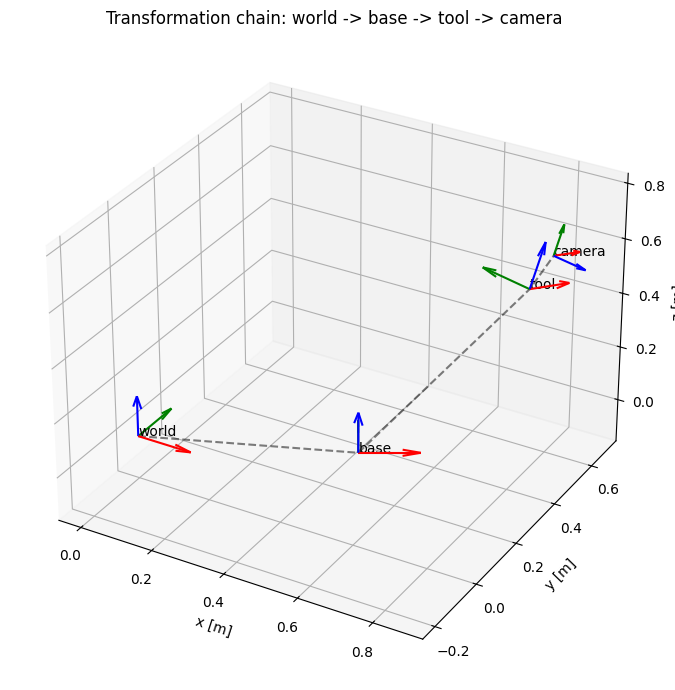

In [14]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

plot_frame(ax, np.eye(4), "world", length=0.15)
plot_frame(ax, T_world_base, "base", length=0.15)
plot_frame(ax, T_world_tool, "tool", length=0.15)
plot_frame(ax, T_world_camera, "camera", length=0.10)

points = np.array([
    np.eye(4)[:3, 3],
    T_world_base[:3, 3],
    T_world_tool[:3, 3],
    T_world_camera[:3, 3],
])

ax.plot(points[:, 0], points[:, 1], points[:, 2], "k--", alpha=0.5)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Transformation chain: world -> base -> tool -> camera")

set_axes_equal(ax)
plt.tight_layout()

figures_dir.mkdir(exist_ok=True)

plt.savefig(figures_dir / "transformation_chain.png", dpi=200)
plt.show()

## Demo 3: Point transformation vs. vector transformation

A homogeneous transformation matrix can be used to transform both points and vectors,
but they are affected differently.

A point has a fixed location in space.
Therefore, transforming a point applies both rotation and translation:

$$
p' = Rp + t
$$

A free vector represents a direction and magnitude, but not a fixed location.
Therefore, transforming a free vector applies only the rotation:

$$
v' = Rv
$$

This distinction is important in robotics.
For example, the origin of a camera frame is transformed as a point,
while a surface normal or direction vector is transformed as a vector.

In [15]:
R = rot_z(np.deg2rad(90))
p = np.array([1.0, 2.0, 0.0])

T = make_transform(R, p)

point = np.array([1.0, 0.0, 0.0])
vector = np.array([1.0, 0.0, 0.0])

transformed_point = transform_point(T, point)
transformed_vector = transform_vector(T, vector)

print("Homogeneous transformation T:")
print(T)

print("\nOriginal point:")
print(point)

print("\nTransformed point:")
print(transformed_point)

print("\nOriginal vector:")
print(vector)

print("\nTransformed vector:")
print(transformed_vector)

Homogeneous transformation T:
[[ 6.123234e-17 -1.000000e+00  0.000000e+00  1.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00  2.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

Original point:
[1. 0. 0.]

Transformed point:
[1. 3. 0.]

Original vector:
[1. 0. 0.]

Transformed vector:
[6.123234e-17 1.000000e+00 0.000000e+00]


In [16]:
expected_point = R @ point + p
expected_vector = R @ vector

print("Expected transformed point:", expected_point)
print("Function result:", transformed_point)
print("Point transformation correct:", np.allclose(transformed_point, expected_point))

print("\nExpected transformed vector:", expected_vector)
print("Function result:", transformed_vector)
print("Vector transformation correct:", np.allclose(transformed_vector, expected_vector))

Expected transformed point: [1. 3. 0.]
Function result: [1. 3. 0.]
Point transformation correct: True

Expected transformed vector: [6.123234e-17 1.000000e+00 0.000000e+00]
Function result: [6.123234e-17 1.000000e+00 0.000000e+00]
Vector transformation correct: True


The point and the vector start with the same numerical coordinates,
but they produce different transformed results.

The point is rotated and translated because it represents a location in space.
The vector is only rotated because it represents direction and magnitude, not a fixed position.

This difference is important when transforming quantities such as surface normals,
force directions, velocity directions, or camera optical axes.

### Why rotation also affects a point

Rotation matters for a point when the point is expressed in a local or moving frame.

For example, if a point is given as

$$
p_{\text{local}} =
\begin{bmatrix}
1 \\
0 \\
0
\end{bmatrix}
$$

this means that the point is located one unit along the local x-axis of that frame.
If the local frame is rotated relative to the world frame,
then the local x-axis does not point in the same direction as the world x-axis.

To express the point in the world frame, both rotation and translation are needed:

$$
p_{\text{world}} = R p_{\text{local}} + t
$$

Here, $R p_{\text{local}}$ describes the local offset expressed in world directions,
and $t$ describes the position of the local frame origin in the world frame.

If the point is exactly at the local frame origin,

$$
p_{\text{local}} =
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
$$

then the rotation has no effect:

$$
p_{\text{world}} = R0 + t = t
$$

Therefore, translation alone is enough only for the origin of the local frame.
For any other point attached to the local frame, rotation also matters.

## Demo 4: Inverse transformation

The inverse of a homogeneous transformation maps coordinates in the opposite direction.

If a transformation maps a point from a local frame to the world frame,

$$
p_{\text{world}} = T_{\text{world,local}} p_{\text{local}}
$$

then the inverse transformation maps the point from the world frame back to the local frame:

$$
p_{\text{local}} = T_{\text{world,local}}^{-1} p_{\text{world}}
$$

For a homogeneous transformation matrix

$$
T =
\begin{bmatrix}
R & p \\
0 & 1
\end{bmatrix}
$$

the inverse is

$$
T^{-1} =
\begin{bmatrix}
R^T & -R^T p \\
0 & 1
\end{bmatrix}
$$

This demo transforms a point from a tool frame to the world frame and then uses
the inverse transformation to recover the original point in the tool frame.

In [17]:
T_world_tool = make_transform(
    rot_z(np.deg2rad(45)) @ rot_y(np.deg2rad(30)),
    np.array([0.5, 0.2, 0.4])
)

p_tool = np.array([0.1, 0.2, 0.3])

p_world = transform_point(T_world_tool, p_tool)

T_tool_world = inverse_transform(T_world_tool)

p_tool_recovered = transform_point(T_tool_world, p_world)

print("T_world_tool:")
print(T_world_tool)

print("\nT_tool_world = inverse_transform(T_world_tool):")
print(T_tool_world)

print("\nOriginal point in tool frame:")
print(p_tool)

print("\nPoint expressed in world frame:")
print(p_world)

print("\nRecovered point in tool frame:")
print(p_tool_recovered)

print("\nRecovered point matches original:", np.allclose(p_tool, p_tool_recovered))

T_world_tool:
[[ 0.61237244 -0.70710678  0.35355339  0.5       ]
 [ 0.61237244  0.70710678  0.35355339  0.2       ]
 [-0.5         0.          0.8660254   0.4       ]
 [ 0.          0.          0.          1.        ]]

T_tool_world = inverse_transform(T_world_tool):
[[ 0.61237244  0.61237244 -0.5        -0.2286607 ]
 [-0.70710678  0.70710678  0.          0.21213203]
 [ 0.35355339  0.35355339  0.8660254  -0.59389753]
 [ 0.          0.          0.          1.        ]]

Original point in tool frame:
[0.1 0.2 0.3]

Point expressed in world frame:
[0.5258819  0.50872462 0.60980762]

Recovered point in tool frame:
[0.1 0.2 0.3]

Recovered point matches original: True


In [18]:
T_identity = T_tool_world @ T_world_tool

print("T_tool_world @ T_world_tool:")
print(T_identity)

print("\nClose to identity:", np.allclose(T_identity, np.eye(4)))

T_tool_world @ T_world_tool:
[[ 1.00000000e+00  0.00000000e+00 -5.55111512e-17 -2.77555756e-17]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  0.00000000e+00  1.00000000e+00 -1.11022302e-16]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Close to identity: True


The inverse transformation correctly recovers the original point up to numerical precision.

This is important because robotic systems often require moving
between coordinate frames in both directions.
For example, a point measured in a camera frame may need to be expressed in the robot base frame,
while a target defined in the robot base frame
may need to be expressed relative to the tool or camera frame.

The inverse transformation provides the mathematically
consistent way to reverse a coordinate transformation.